Connect to dataset on google drive

In [ ]:
# Load the Drive helper and mount
from google.colab import drive

# This will prompt for authorization.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import all required libraries
import os
import cv2
import json
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import Xception
%matplotlib inline
np.random.seed(2)
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping
from keras.preprocessing.image import img_to_array# optional if you need to save numpy array
from keras.preprocessing.image import load_img


Load the frames extracted from the four folders into four arrays with a shape of 128 * 128, and perform flattening and normalization by dividing each pixel value by 256.

In [ ]:
input_shape = (128, 128, 3)

real_data = [f for f in os.listdir('/content/drive/MyDrive/RARV_frames/') if f.endswith('.png')]
real_data_2 = [f for f in os.listdir('/content/drive/MyDrive/FARV_frames/') if f.endswith('.png')]

fake_data = [f for f in os.listdir('/content/drive/MyDrive/RAFV_frames/') if f.endswith('.png')]
fake_data_2 = [f for f in os.listdir('/content/drive/MyDrive/FAFV_frames/') if f.endswith('.png')]

X=[]
Y=[]
ctr=0

for img in real_data:
    X.append(img_to_array(load_img('/content/drive/MyDrive/RARV_frames/'+img)).flatten() / 255.0)
    Y.append(1)
    ctr+=1

for img in real_data_2:
    X.append(img_to_array(load_img('/content/drive/MyDrive/FARV_frames/'+img)).flatten() / 255.0)
    Y.append(1)
    ctr+=1

for img in fake_data:
    X.append(img_to_array(load_img('/content/drive/MyDrive/RAFV_frames/'+img)).flatten() / 255.0)
    Y.append(0)
    ctr+=1

for img in fake_data_2:
    X.append(img_to_array(load_img('/content/drive/MyDrive/FAFV_frames/'+img)).flatten() / 255.0)
    Y.append(0)
    ctr+=1

#Normalization
X = np.array(X)
Y = np.array(Y)

#Reshape
X = X.reshape(-1, 128, 128, 3)



In [ ]:
#Train-Test split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size = 0.25, random_state=42, stratify=Y)


In next 2 cells, in FakeAVCeleb dataset, real samples are minority class so we oversample real samples by extracting real samples then implementing data augmentation techniques on them, including rotation, shear, zoom, horizontal flip, fill mode, brightness adjustment, and channel shift.

In [ ]:
from sklearn.utils import resample

# Assuming X_train is your image data and Y_train is the corresponding labels

# Find indices of real samples
real_indices = np.where(Y_train == 1)[0]

# Extract real samples
X_real = X_train[real_indices]
Y_real = Y_train[real_indices]

# Find indices of fake samples
fake_indices = np.where(Y_train == 0)[0]

# Extract fake samples
X_fake = X_train[fake_indices]
Y_fake = Y_train[fake_indices]

# Resample the real samples to match the number of fake samples
X_real_oversampled, Y_real_oversampled = resample(X_real, Y_real, replace=True, n_samples=len(X_fake), random_state=42)

# Create the ImageDataGenerator with augmentations
datagen = ImageDataGenerator(
    rotation_range=10,       # Small rotations
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.7, 1.3],  # Brightness adjustment
    channel_shift_range=10,     # Hue randomization
)

# Fit the generator on the oversampled real data
datagen.fit(X_real_oversampled)

In [ ]:

# Combine oversampled real samples with original fake samples
X_train = np.concatenate([X_real_oversampled, X_fake])
Y_train = np.concatenate([Y_real_oversampled, Y_fake])

# Shuffle the oversampled data
shuffle_indices = np.random.permutation(len(X_train))
X_train = X_train[shuffle_indices]
Y_train = Y_train[shuffle_indices]


In this phase, the model is constructed utilizing the DenseNet201 pre-trained architecture. The top layers are excluded, retaining only the base layers of the DenseNet201 model. Fine-tuning is performed on the initial 50 layers of the DenseNet201 model, while the subsequent layers remain frozen. A fully connected layer with 128 neurons and a rectified linear unit (ReLU) activation function is added, followed by dropout with a rate of 0.7. Finally, an output layer with a single neuron and a sigmoid activation function is appended to the model.


In [ ]:
from keras.applications import DenseNet201
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D
from keras.optimizers import Adam

# Load DenseNet model with pre-trained weights
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the layers in the base model
base_model.trainable = True

# Choose the layers you want to fine-tune
fine_tune_at = 50  # Adjust this value based on the architecture of InceptionV3
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Add custom layers for fine-tuning
x = GlobalAveragePooling2D()(base_model.output)
Dropout(0.7),
keras.layers.Dense(128, activation='relu'),
Dropout(0.7),
x = Dense(1, activation='sigmoid')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer=Adam(lr=0.0000001), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0,
                               patience=20,
                               verbose=0, mode='auto', restore_best_weights=True)

# Train the model with early stopping and model checkpoint
history = model.fit(X_train, Y_train,
                    batch_size=32,
                    epochs=50,
                    validation_data=(X_val, Y_val),
                    callbacks=[early_stopping]
                    )


74836368/74836368 [==============================] - 0s 0us/step


Epoch 1/50
375/375 [==============================] - 190s 199ms/step - loss: 0.1599 - accuracy: 0.9411 - val_loss: 0.2545 - val_accuracy: 0.9286
Epoch 2/50
375/375 [==============================] - 66s 176ms/step - loss: 0.0529 - accuracy: 0.9818 - val_loss: 0.0959 - val_accuracy: 0.9729
Epoch 3/50
375/375 [==============================] - 68s 180ms/step - loss: 0.0158 - accuracy: 0.9954 - val_loss: 0.1620 - val_accuracy: 0.9519
Epoch 4/50
375/375 [==============================] - 68s 181ms/step - loss: 0.0265 - accuracy: 0.9921 - val_loss: 0.0717 - val_accuracy: 0.9852
Epoch 5/50
375/375 [==============================] - 68s 181ms/step - loss: 0.0126 - accuracy: 0.9962 - val_loss: 0.0658 - val_accuracy: 0.9848
Epoch 6/50
375/375 [==============================] - 68s 180ms/step - loss: 0.0193 - accuracy: 0.9942 - val_loss: 0.1365 - val_accuracy: 0.9795
Epoch 7/50
375/375 [==============================] - 66s 176ms/step - loss: 0.0143 - accuracy: 0.9964 - val_loss: 0.0585 - val_a

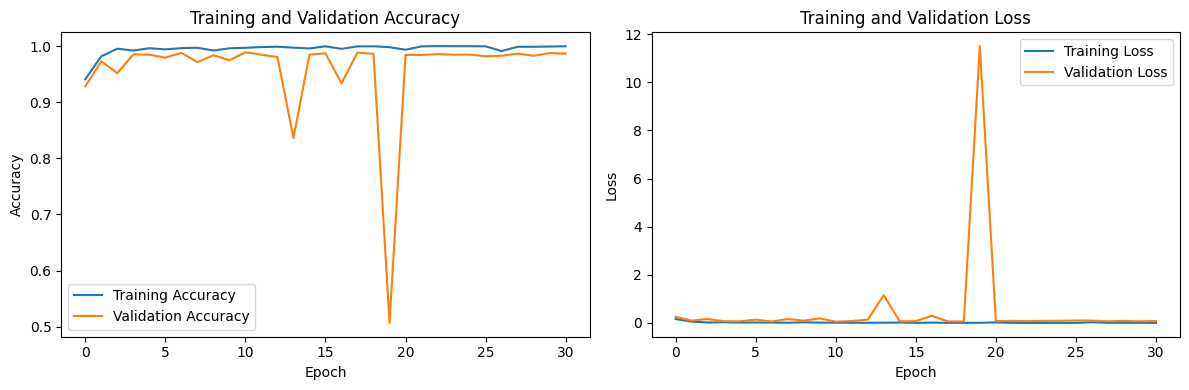

In [ ]:

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()

In [ ]:
# Save the entire model to a file after training
model.save("/content/drive/MyDrive/epochs_50_layers_best_weights_32_50_aug_densenet_model.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
